# Dallas Mavericks Player Scoring Efficiency Analysis

## Objective

Analyze player performance data from the 2025-26 Dallas Mavericks roster to evaluate scoring efficiency, player value, and factors associated with offensive production.

## Objective (Thai)

วิเคราะห์ข้อมูลผู้เล่นของทีม Dallas Mavericks ฤดูกาล 2025-26 เพื่อประเมินประสิทธิภาพการทำคะแนน คุณค่าของผู้เล่น และปัจจัยที่เกี่ยวข้องกับผลงานเกมรุก

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"

from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)


## 2. Load Datasets

In [2]:
import pandas as pd
import os

folder_path = r"S:\NBAproject\dataset\raw"

per_game = pd.read_html(os.path.join(folder_path,"Dallas2025-2026_pergame.xls"))[0]

totals = pd.read_html(os.path.join(folder_path,"Dallas2025-2026_totals.xls"))[0]

per36 = pd.read_html(os.path.join(folder_path,"Dallas2025-2026_per36mins.xls"))[0]

per100 = pd.read_html(os.path.join(folder_path,"Dallas2025-2026_Per100Poss.xls"))[0]

advanced = pd.read_html(os.path.join(folder_path,"Dallas2025-2026_Advanced.xls"))[0]

adjusted_shooting = pd.read_html(os.path.join(folder_path,"Dallas2025-2026_Adjusted_Shooting.xls"))[0]

shooting = pd.read_html(os.path.join(folder_path,"Dallas2025-2026_Shooting.xls"))[0]

play_by_play = pd.read_html(os.path.join(folder_path,"Dallas2025-2026_Play_by_Play.xls"))[0]

print("All datasets loaded successfully.")

All datasets loaded successfully.


## 3. Dataset Overview

This section reviews the size of each dataset and provides a summary of the available information.

ส่วนนี้ใช้ตรวจสอบขนาดของชุดข้อมูลแต่ละชุด และสรุปข้อมูลเบื้องต้นที่สามารถนำไปใช้ในการวิเคราะห์ได้

In [3]:
datasets = {
    "Per Game": per_game,
    "Totals": totals,
    "Per 36": per36,
    "Per 100 Poss": per100,
    "Advanced": advanced,
    "Adjusted Shooting": adjusted_shooting,
    "Shooting": shooting,
    "Play by Play": play_by_play
}

overview = []

for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

overview_df = pd.DataFrame(overview)

overview_df

,Dataset,Rows,Columns
0,Per Game,24,30
1,Totals,24,30
2,Per 36,23,30
3,Per 100 Poss,23,31
4,Advanced,24,28
5,Adjusted Shooting,24,26
6,Shooting,24,30
7,Play by Play,24,24


## 4. Data Inspection

Before combining datasets, it is important to review the structure and contents of each dataset. This step helps identify key variables and potential data quality issues.

ก่อนรวมชุดข้อมูลเข้าด้วยกัน จำเป็นต้องตรวจสอบโครงสร้างและเนื้อหาของแต่ละชุดข้อมูล เพื่อระบุคอลัมน์สำคัญและปัญหาที่อาจส่งผลต่อการวิเคราะห์ในขั้นตอนถัดไป

In [4]:
#4.1 Per Game Dataset

per_game.head()
per_game.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      23 non-null     float64
 1   Player  24 non-null     object 
 2   Age     23 non-null     float64
 3   Pos     23 non-null     object 
 4   G       24 non-null     int64  
 5   GS      24 non-null     int64  
 6   MP      24 non-null     float64
 7   FG      24 non-null     float64
 8   FGA     24 non-null     float64
 9   FG%     24 non-null     float64
 10  3P      24 non-null     float64
 11  3PA     24 non-null     float64
 12  3P%     21 non-null     float64
 13  2P      24 non-null     float64
 14  2PA     24 non-null     float64
 15  2P%     24 non-null     float64
 16  eFG%    24 non-null     float64
 17  FT      24 non-null     float64
 18  FTA     24 non-null     float64
 19  FT%     24 non-null     float64
 20  ORB     24 non-null     float64
 21  DRB     24 non-null     float64
 22  TRB 

### Observations

The Per Game dataset contains 24 records and 30 columns. Most numerical statistics are complete. However, several columns contain missing values, including Age, Position, and Three-Point Percentage.

The Awards column contains only one non-null value and may not be useful for the main analysis.

ชุดข้อมูล Per Game มีทั้งหมด 24 แถว และ 30 คอลัมน์ โดยสถิติส่วนใหญ่มีข้อมูลครบถ้วน อย่างไรก็ตาม พบว่าบางคอลัมน์มีข้อมูลที่หายไป เช่น Age, Position และ Three-Point Percentage

คอลัมน์ Awards มีข้อมูลเพียงหนึ่งรายการ จึงอาจไม่มีประโยชน์ต่อการวิเคราะห์หลักของโปรเจกต์นี้


In [5]:
per_game.tail()

,Rk,Player,Age,Pos,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
19,20.0,Jaden Hardy,23.0,SG,34,4,12.6,2.3,5.7,0.402,1.4,3.6,0.371,0.9,2.1,0.457,0.521,0.9,1.2,0.775,0.3,1.1,1.4,0.9,0.3,0.1,0.8,1.1,6.9,NaN
20,21.0,Jeremiah Robinson-Earl,25.0,PF,5,0,12.2,1.6,3.4,0.471,0.4,1.6,0.250,1.2,1.8,0.667,0.529,0.8,0.8,1.000,0.8,2.2,3.0,0.6,0.4,0.0,0.4,0.6,4.4,NaN
21,22.0,AJ Johnson,21.0,SG,23,0,10.4,1.3,4.0,0.323,0.2,1.4,0.156,1.1,2.7,0.410,0.349,1.1,1.2,0.893,0.3,0.8,1.0,1.1,0.2,0.1,0.5,0.7,3.9,NaN
22,23.0,Miles Kelly,23.0,PG,14,0,9.6,1.1,3.1,0.364,0.7,2.4,0.303,0.4,0.8,0.545,0.477,0.1,0.1,1.000,0.4,1.4,1.7,0.9,0.3,0.1,0.4,0.9,3.1,NaN
23,NaN,Team Totals,NaN,NaN,82,82,242.1,41.9,89.8,0.466,11.0,31.9,0.344,30.9,57.9,0.533,0.527,19.5,25.8,0.755,10.5,34.2,44.7,25.3,7.5,5.2,14.5,18.4,114.1,NaN


In [6]:
per_game.isnull().sum().sort_values(ascending=False)

Awards    23
3P%        3
Pos        1
Age        1
Rk         1
G          0
GS         0
MP         0
FGA        0
FG         0
FG%        0
3P         0
3PA        0
Player     0
2P         0
2PA        0
eFG%       0
2P%        0
FTA        0
FT%        0
ORB        0
FT         0
DRB        0
TRB        0
STL        0
AST        0
BLK        0
TOV        0
PF         0
PTS        0
dtype: int64

## 5. Data Quality Assessment

This section evaluates potential data quality issues before the cleaning process. The assessment focuses on missing values and non-player records that may affect the analysis.

ส่วนนี้ใช้ประเมินปัญหาด้านคุณภาพข้อมูลก่อนเริ่มกระบวนการทำความสะอาดข้อมูล โดยเน้นตรวจสอบข้อมูลที่หายไปและแถวข้อมูลที่ไม่ใช่ผู้เล่น ซึ่งอาจส่งผลต่อผลลัพธ์ของการวิเคราะห์

### Missing Values Summary

The missing value assessment identified a small number of incomplete records. Most variables contain complete information, while a few columns contain missing values.

การตรวจสอบข้อมูลที่หายไปพบว่าชุดข้อมูลส่วนใหญ่มีข้อมูลครบถ้วน โดยมีเพียงบางคอลัมน์ที่พบค่าหายไปในจำนวนเล็กน้อย

In [7]:
missing_summary = (
    per_game.isnull()
            .sum()
            .reset_index()
)

missing_summary.columns = ["Column", "Missing Values"]

missing_summary[missing_summary["Missing Values"] > 0]

,Column,Missing Values
0,Rk,1
2,Age,1
3,Pos,1
12,3P%,3
29,Awards,23


### Findings

The missing value assessment indicates that most variables are complete. The Awards column contains missing values for nearly all records and is not expected to contribute to the analysis.

A small number of missing values were identified in Age, Position, and Three-Point Percentage. These values will be reviewed during the cleaning process.

ผลการตรวจสอบพบว่าตัวแปรส่วนใหญ่มีข้อมูลครบถ้วน คอลัมน์ Awards มีข้อมูลหายไปเกือบทั้งหมดและคาดว่าจะไม่มีบทบาทสำคัญต่อการวิเคราะห์

นอกจากนี้ยังพบข้อมูลที่หายไปในคอลัมน์ Age, Position และ Three-Point Percentage ในจำนวนเล็กน้อย ซึ่งจะมีการตรวจสอบเพิ่มเติมในขั้นตอนการทำความสะอาดข้อมูล

### Summary Row Assessment

The dataset may contain summary records that represent team-level statistics rather than individual player information. These records should be identified and removed before analysis.

ชุดข้อมูลอาจมีแถวสรุปผลที่แสดงสถิติรวมของทั้งทีมแทนข้อมูลผู้เล่นรายบุคคล ซึ่งควรได้รับการตรวจสอบและลบออกก่อนการวิเคราะห์

## 6. Data Cleaning

This section prepares the datasets for integration and analysis. Records that are not related to individual players are removed, and unnecessary columns are reviewed.

ส่วนนี้ใช้เตรียมข้อมูลสำหรับการรวมชุดข้อมูลและการวิเคราะห์ โดยจะลบข้อมูลที่ไม่เกี่ยวข้องกับผู้เล่นรายบุคคล และตรวจสอบคอลัมน์ที่ไม่จำเป็นต่อการวิเคราะห์

In [8]:
advanced.tail()
per36.tail()
per100.tail()
shooting.tail()

Unnamed: 0_level_0      Unnamed: 1_level_0 Unnamed: 2_level_0  \
                   Rk                  Player                Age   
19               20.0             Miles Kelly               23.0   
20               21.0              Tyus Jones               29.0   
21               22.0        Dereck Lively II               21.0   
22               23.0  Jeremiah Robinson-Earl               25.0   
23                NaN             Team Totals                NaN   

   Unnamed: 3_level_0 Unnamed: 4_level_0 Unnamed: 5_level_0  \
                  Pos                  G                 GS   
19                 PG                 14                  0   
20                 PG                  8                  2   
21                  C                  7                  4   
22                 PF                  5                  0   
23                NaN                 82                 82   

   Unnamed: 6_level_0 Unnamed: 7_level_0 Unnamed: 8_level_0  \
                   MP                FG%              Dist.   
19                134              0.364               20.1   
20                133              0.382               18.9   
21                115              0.611                2.0   
22                 61              0.471               12.9   
23              19857              0.466               13.0   

   % of FGA by Distance                                    FG% by Distance  \
                     2P    0-3   3-10  10-16  16-3P     3P              2P   
19                0.250  0.091  0.068  0.023  0.068  0.750           0.545   
20                0.441  0.059  0.147  0.118  0.118  0.559           0.600   
21                1.000  0.778  0.222  0.000  0.000  0.000           0.611   
22                0.529  0.353  0.118  0.000  0.059  0.471           0.667   
23                0.645  0.229  0.236  0.108  0.072  0.355           0.533   

                                      % of FG Ast'd         Dunks       \
      0-3   3-10  10-16  16-3P     3P            2P     3P   %FGA    #   
19  0.750  0.333  0.000  0.667  0.303         0.833  0.900  0.000    0   
20  0.500  0.600  0.750  0.500  0.211         0.667  0.750  0.000    0   
21  0.643  0.500    NaN    NaN    NaN         0.727    NaN  0.444    8   
22  0.833  0.500    NaN  0.000  0.250         0.500  1.000  0.118    2   
23  0.715  0.455  0.428  0.368  0.344         0.503  0.888  0.065  414   

   Corner 3s        1/2 Court     Unnamed: 29_level_0  
        %3PA    3P%      Att. Md.              Awards  
19     0.606  0.450         0   0                 NaN  
20     0.158  0.333         0   0                 NaN  
21       NaN    NaN         0   0                 NaN  
22     0.875  0.143         0   0                 NaN  
23     0.289  0.377         1   0                 NaN

### Team Summary Records

All datasets contain a summary row labeled "Team Totals". Since the objective of this project is player-level analysis, these records will be removed from every dataset.

ทุกชุดข้อมูลมีแถวสรุปผลชื่อ "Team Totals" ซึ่งเป็นข้อมูลรวมของทั้งทีม ไม่ใช่ข้อมูลผู้เล่นรายบุคคล ดังนั้นแถวเหล่านี้จะถูกลบออกจากทุกชุดข้อมูลก่อนการวิเคราะห์

In [9]:
def flatten_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            col[-1] if col[-1] != "" else col[0]
            for col in df.columns
        ]
    return df


def remove_team_totals(df):
    df = flatten_columns(df)
    
    if "Player" in df.columns:
        df = df[df["Player"] != "Team Totals"]
        
    return df


per_game = remove_team_totals(per_game)
totals = remove_team_totals(totals)
per36 = remove_team_totals(per36)
per100 = remove_team_totals(per100)
advanced = remove_team_totals(advanced)
adjusted_shooting = remove_team_totals(adjusted_shooting)
shooting = remove_team_totals(shooting)
play_by_play = remove_team_totals(play_by_play)

print("Team Totals removed successfully.")

Team Totals removed successfully.


In [10]:
datasets = {
    "Per Game": per_game,
    "Totals": totals,
    "Per 36": per36,
    "Per 100 Poss": per100,
    "Advanced": advanced,
    "Adjusted Shooting": adjusted_shooting,
    "Shooting": shooting,
    "Play by Play": play_by_play
}

for name, df in datasets.items():
    print(name, df.shape)

Per Game (23, 30)
Totals (23, 30)
Per 36 (23, 30)
Per 100 Poss (23, 31)
Advanced (23, 28)
Adjusted Shooting (23, 26)
Shooting (23, 30)
Play by Play (23, 24)


After removing the Team Totals row, all datasets contain 23 player records. This confirms that the data is now focused on individual player-level analysis.

หลังจากลบแถว Team Totals แล้ว ทุกชุดข้อมูลเหลือข้อมูลผู้เล่นทั้งหมด 23 คน ซึ่งแสดงว่าข้อมูลพร้อมสำหรับการวิเคราะห์ในระดับผู้เล่นรายบุคคล

In [11]:
#Drop Rk and Awards
def drop_unnecessary_columns(df):
    columns_to_drop = ["Rk", "Awards"]
    
    existing_columns = [
        col for col in columns_to_drop 
        if col in df.columns
    ]
    
    return df.drop(columns=existing_columns)


per_game = drop_unnecessary_columns(per_game)
totals = drop_unnecessary_columns(totals)
per36 = drop_unnecessary_columns(per36)
per100 = drop_unnecessary_columns(per100)
advanced = drop_unnecessary_columns(advanced)
adjusted_shooting = drop_unnecessary_columns(adjusted_shooting)
shooting = drop_unnecessary_columns(shooting)
play_by_play = drop_unnecessary_columns(play_by_play)

print("Unnecessary columns removed successfully.")

Unnecessary columns removed successfully.


In [12]:
datasets = {
    "Per Game": per_game,
    "Totals": totals,
    "Per 36": per36,
    "Per 100 Poss": per100,
    "Advanced": advanced,
    "Adjusted Shooting": adjusted_shooting,
    "Shooting": shooting,
    "Play by Play": play_by_play
}

In [13]:
for name, df in datasets.items():
    print(name, df.columns.tolist())

Per Game ['Player', 'Age', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']
Totals ['Player', 'Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Trp-Dbl']
Per 36 ['Player', 'Age', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']
Per 100 Poss ['Player', 'Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'ORtg', 'DRtg']
Advanced ['Player', 'Age', 'Pos', 'G', 'GS', 'MP', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'D

In [14]:
for name, df in datasets.items():
    print(name, df["Player"].nunique())

Per Game 23
Totals 23
Per 36 23
Per 100 Poss 23
Advanced 23
Adjusted Shooting 23
Shooting 23
Play by Play 23


## 7. Data Integration

This section combines player statistics from multiple datasets into one master dataset. The Player column is used as the common key for merging.

ส่วนนี้ใช้รวมสถิติผู้เล่นจากหลายชุดข้อมูลเข้าด้วยกันเป็นชุดข้อมูลหลัก โดยใช้คอลัมน์ Player เป็นตัวเชื่อมข้อมูล

In [15]:
from functools import reduce

merge_key = "Player"

dataframes_to_merge = [
    per_game,
    per36,
    per100,
    advanced,
    adjusted_shooting,
    shooting,
    play_by_play
]

master_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=merge_key,
        how="left",
        suffixes=("", "_dup")
    ),
    dataframes_to_merge
)

duplicate_columns = [
    col for col in master_df.columns
    if col.endswith("_dup")
]

master_df = master_df.drop(columns=duplicate_columns)

master_df.shape

(23, 90)

In [16]:
master_df.head()

,Player,Age,Pos,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,ORtg,DRtg,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,FG+,2P+,3P+,eFG+,FT+,TS+,FTr+,3PAr+,FG Add,TS Add,Dist.,0-3,3-10,10-16,16-3P,0-3,3-10,10-16,16-3P,%FGA,#,%3PA,Att.,Md.,PG%,SG%,SF%,PF%,C%,OnCourt,On-Off,BadPass,LostBall,Shoot,Off.,Shoot,Off.,PGA,And1,Blkd
0,Cooper Flagg,19.0,SF,70,70,33.5,8.0,17.1,0.468,1.0,3.5,0.295,7.0,13.6,0.513,0.498,4.0,4.9,0.827,1.2,5.4,6.7,4.5,1.2,0.9,2.3,2.0,21.0,110,115,17.9,0.548,0.204,0.286,3.9,17.0,10.5,21.5,1.7,2.3,10.7,26.9,1.3,2.5,3.8,0.078,1.0,0.4,1.4,2.0,99,93,82.0,91,106,94,109,49,-113.0,-90.4,11.5,0.218,0.311,0.151,0.116,0.742,0.453,0.444,0.331,0.071,74,0.119,0,0,0,1,37,60,1,-5.7,0.2,52,78,77,11,157,3,767,39,79
1,Anthony Davis,32.0,PF,20,20,31.3,8.5,16.7,0.506,0.5,1.9,0.270,8.0,14.9,0.535,0.521,3.0,4.1,0.728,3.1,8.0,11.1,2.8,1.1,1.7,2.1,2.1,20.4,111,111,21.5,0.551,0.111,0.243,10.6,26.7,18.7,15.1,1.7,4.5,10.0,27.5,0.4,1.0,1.3,0.103,1.5,0.9,2.4,0.7,107,97,75.0,95,93,95,92,27,-16.5,-22.8,9.2,0.332,0.278,0.156,0.123,0.730,0.462,0.365,0.390,0.141,42,0.135,0,0,0,0,0,11,89,-4.0,2.1,15,22,28,2,38,4,130,10,14
2,P.J. Washington,27.0,PF,56,53,31.0,5.3,11.8,0.450,1.4,4.2,0.325,3.9,7.6,0.519,0.508,2.2,3.3,0.687,1.5,5.5,7.0,1.8,1.0,1.1,1.7,2.1,14.2,105,115,13.1,0.537,0.356,0.277,5.2,18.7,12.0,8.1,1.5,2.9,11.3,20.1,-0.3,2.0,1.7,0.046,-1.7,0.1,-1.6,0.2,96,94,90.0,93,88,92,105,86,-50.1,-65.2,12.1,0.243,0.324,0.059,0.018,0.669,0.441,0.359,0.417,0.088,53,0.415,0,0,0,0,2,85,14,-6.9,-2.1,41,37,68,10,92,5,235,24,43
3,Naji Marshall,28.0,SF,74,47,29.5,5.7,11.1,0.510,0.8,2.9,0.291,4.8,8.2,0.587,0.548,3.1,4.1,0.760,0.9,3.8,4.7,3.3,1.1,0.1,1.6,1.9,15.2,116,117,15.4,0.592,0.259,0.365,3.2,13.6,8.4,16.4,1.8,0.2,11.1,20.5,2.5,1.8,4.3,0.095,-0.7,0.1,-0.6,0.8,108,107,81.0,100,97,102,139,63,4.0,19.8,11.3,0.210,0.370,0.135,0.026,0.773,0.553,0.459,0.238,0.012,10,0.469,0,0,0,22,57,20,0,-4.8,2.1,61,28,71,18,143,4,580,34,47
4,Max Christie,22.0,SG,77,68,29.1,4.2,9.4,0.441,2.3,5.8,0.404,1.8,3.6,0.502,0.566,1.6,1.8,0.899,0.2,3.0,3.2,2.0,0.6,0.4,1.2,1.3,12.3,113,119,11.0,0.601,0.615,0.192,0.7,10.9,5.9,9.3,1.0,1.0,10.9,16.5,1.3,1.4,2.7,0.058,-1.0,-0.6,-1.5,0.3,94,91,112.0,104,115,103,73,148,28.8,30.9,18.0,0.137,0.141,0.062,0.046,0.717,0.373,0.422,0.364,0.043,26,0.357,0,0,26,68,5,1,0,-6.9,-2.5,43,35,67,6,55,13,358,9,41


In [17]:
master_df.isnull().sum().sort_values(ascending=False).head(20)

10-16     6
3P%       3
%3PA      3
16-3P     3
3P+       3
MP        0
Pos       0
G         0
GS        0
Player    0
3P        0
3PA       0
2P        0
2PA       0
2P%       0
eFG%      0
FT        0
FTA       0
FT%       0
ORB       0
dtype: int64

The datasets were successfully merged into a master dataset with 23 player records and 90 columns. This dataset combines traditional statistics, advanced metrics, shooting data, and play-by-play related variables.

ชุดข้อมูลทั้งหมดถูกรวมเป็น master dataset สำเร็จ โดยมีข้อมูลผู้เล่น 23 คน และ 90 คอลัมน์ ข้อมูลชุดนี้รวมทั้งสถิติพื้นฐาน สถิติขั้นสูง ข้อมูลการยิง และตัวแปรที่เกี่ยวข้องกับ play-by-play

## 8. Feature Engineering

This section creates additional variables to evaluate player scoring efficiency and value. These metrics are designed to compare players beyond traditional points per game.

ส่วนนี้สร้างตัวแปรเพิ่มเติมเพื่อประเมินประสิทธิภาพการทำคะแนนและคุณค่าของผู้เล่น ตัวชี้วัดเหล่านี้ใช้เปรียบเทียบผู้เล่นให้ลึกกว่าการดูคะแนนเฉลี่ยต่อเกม

### 8.1 Points Per Minute

Points Per Minute measures how many points a player scores for every minute played. This metric helps compare players with different playing time.

Points Per Minute ใช้วัดจำนวนคะแนนที่ผู้เล่นทำได้ต่อหนึ่งนาทีที่อยู่ในสนาม ซึ่งช่วยให้สามารถเปรียบเทียบผู้เล่นที่มีเวลาเล่นแตกต่างกันได้

In [18]:
master_df["PTS_per_Min"] = (
    master_df["PTS"] /
    master_df["MP"]
)

master_df[
    ["Player", "PTS", "MP", "PTS_per_Min"]
].head()

,Player,PTS,MP,PTS_per_Min
0,Cooper Flagg,21.0,33.5,0.626866
1,Anthony Davis,20.4,31.3,0.651757
2,P.J. Washington,14.2,31.0,0.458065
3,Naji Marshall,15.2,29.5,0.515254
4,Max Christie,12.3,29.1,0.422680


### 8.2 Projected Points Per 36 Minutes

Per-36 statistics are commonly used in basketball analytics because they normalize production across players with different playing time. This metric estimates how many points a player would score if they played 36 minutes.

สถิติแบบ Per-36 เป็นแนวทางที่นิยมใช้ในการวิเคราะห์บาสเกตบอล เนื่องจากช่วยปรับผลงานของผู้เล่นให้อยู่บนพื้นฐานเวลาเล่นที่เท่ากัน ตัวชี้วัดนี้ใช้ประมาณจำนวนคะแนนที่ผู้เล่นจะทำได้หากลงเล่น 36 นาที

In [19]:
master_df["Projected_PTS_36"] = (
    master_df["PTS_per_Min"] * 36
)

master_df[
    ["Player", "Projected_PTS_36"]
].sort_values(
    by="Projected_PTS_36",
    ascending=False
).head(10)

,Player,Projected_PTS_36
1,Anthony Davis,23.463259
0,Cooper Flagg,22.567164
5,Brandon Williams,21.081081
19,Jaden Hardy,19.714286
6,Klay Thompson,19.410138
12,D'Angelo Russell,19.326316
3,Naji Marshall,18.549153
8,Marvin Bagley III,18.504673
9,Khris Middleton,17.061611
2,P.J. Washington,16.490323


### 8.3 Points Per Field Goal Attempt

This metric measures the average number of points generated for each field goal attempt. Higher values indicate that a player converts scoring opportunities more efficiently.

ตัวชี้วัดนี้ใช้วัดจำนวนคะแนนเฉลี่ยที่ผู้เล่นสร้างได้ต่อหนึ่งครั้งที่พยายามยิง ยิ่งค่ามาก แสดงว่าผู้เล่นสามารถเปลี่ยนโอกาสการยิงให้เป็นคะแนนได้อย่างมีประสิทธิภาพ

In [20]:
master_df["PTS_per_FGA"] = (
    master_df["PTS"] /
    master_df["FGA"]
)

master_df[
    ["Player", "PTS_per_FGA"]
].sort_values(
    by="PTS_per_FGA",
    ascending=False
).head(10)

,Player,PTS_per_FGA
16,Dwight Powell,2.062500
7,Daniel Gafford,1.666667
14,Dereck Lively II,1.653846
17,Moussa Cisse,1.500000
8,Marvin Bagley III,1.466667
5,Brandon Williams,1.397849
3,Naji Marshall,1.369369
4,Max Christie,1.308511
20,Jeremiah Robinson-Earl,1.294118
11,John Poulakidas,1.257143


### 8.4 True Shooting Impact

True Shooting Impact combines scoring volume and shooting efficiency into a single metric. Players who score more points while maintaining strong shooting efficiency will receive higher values.

True Shooting Impact เป็นตัวชี้วัดที่รวมปริมาณการทำคะแนนและประสิทธิภาพการยิงเข้าด้วยกัน ผู้เล่นที่ทำคะแนนได้มากและมีประสิทธิภาพการยิงสูงจะมีค่าตัวชี้วัดสูงกว่า

In [21]:
master_df["TS_Impact"] = (
    master_df["PTS"] *
    master_df["TS%"]
)

master_df[
    ["Player", "PTS", "TS%", "TS_Impact"]
].sort_values(
    by="TS_Impact",
    ascending=False
).head(10)

,Player,PTS,TS%,TS_Impact
0,Cooper Flagg,21.0,0.548,11.5080
1,Anthony Davis,20.4,0.551,11.2404
3,Naji Marshall,15.2,0.592,8.9984
2,P.J. Washington,14.2,0.537,7.6254
5,Brandon Williams,13.0,0.572,7.4360
4,Max Christie,12.3,0.601,7.3923
8,Marvin Bagley III,11.0,0.652,7.1720
7,Daniel Gafford,9.5,0.677,6.4315
6,Klay Thompson,11.7,0.541,6.3297
11,John Poulakidas,8.8,0.611,5.3768


## 9. Player Qualification Filter

Before creating the final scoring efficiency index, a minimum games played requirement is applied to the dataset. Players with very limited appearances may produce unstable efficiency metrics because their performance is based on a small sample size.

A threshold of 20 games was selected to exclude players with very limited appearances while still retaining enough players for analysis.

ก่อนสร้างดัชนีประสิทธิภาพการทำคะแนนขั้นสุดท้าย ได้มีการกำหนดเกณฑ์ขั้นต่ำของจำนวนเกมที่ลงเล่น ผู้เล่นที่ลงเล่นจำนวนน้อยอาจมีค่าสถิติที่ไม่เสถียร เนื่องจากข้อมูลมาจากกลุ่มตัวอย่างขนาดเล็ก

เลือกเกณฑ์ 20 เกมเพื่อคัดกรองผู้เล่นที่มีโอกาสลงสนามจำกัดเกินไป แต่ยังคงรักษาจำนวนผู้เล่นที่เพียงพอสำหรับการวิเคราะห์

In [22]:
minimum_games = 20

qualified_players = master_df[
    master_df["G"] >= minimum_games
].copy()

print("Players before filter:", len(master_df))
print("Players after filter:", len(qualified_players))

Players before filter: 23
Players after filter: 17


In [23]:
master_df[
    ["Player", "G", "GS", "MP"]
].sort_values(
    by="G"
)

,Player,G,GS,MP
20,Jeremiah Robinson-Earl,5,0,12.2
14,Dereck Lively II,7,4,16.4
13,Tyus Jones,8,2,16.6
18,Tyler Smith,12,0,13.8
11,John Poulakidas,13,0,19.5
22,Miles Kelly,14,0,9.6
1,Anthony Davis,20,20,31.3
8,Marvin Bagley III,22,4,21.4
21,AJ Johnson,23,0,10.4
12,D'Angelo Russell,26,3,19.0


## 10. Mavericks Scoring Efficiency Index (MSEI)

The Mavericks Scoring Efficiency Index (MSEI) is a custom metric developed for this project to evaluate scoring performance using multiple dimensions of offensive contribution.

The metric combines projected scoring output, shooting efficiency, and turnover control into a single value. Players who score more efficiently while maintaining lower turnover rates will receive higher MSEI scores.

This index is not intended to replace advanced metrics such as PER or Win Shares. Instead, it provides a simple framework for comparing scoring efficiency among Dallas Mavericks players using the available dataset.

ดัชนี Mavericks Scoring Efficiency Index (MSEI) เป็นตัวชี้วัดที่พัฒนาขึ้นสำหรับโครงงานนี้ เพื่อประเมินประสิทธิภาพการทำคะแนนโดยพิจารณาหลายองค์ประกอบของเกมรุกร่วมกัน

ตัวชี้วัดนี้รวมความสามารถในการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอลไว้ในค่าเดียว ผู้เล่นที่ทำคะแนนได้มาก มีประสิทธิภาพการยิงสูง และเสียบอลน้อย จะได้รับค่า MSEI ที่สูงกว่า

ดัชนีนี้ไม่ได้ถูกออกแบบมาเพื่อทดแทนตัวชี้วัดขั้นสูง เช่น PER หรือ Win Shares แต่ใช้เป็นกรอบการวิเคราะห์อย่างง่ายสำหรับเปรียบเทียบประสิทธิภาพการทำคะแนนของผู้เล่น Dallas Mavericks จากข้อมูลที่มีอยู่

### MSEI Formula

The MSEI metric is calculated as:

MSEI = (Projected_PTS_36 × TS%) / (1 + TOV%)

where:

- Projected_PTS_36 = projected points scored per 36 minutes
- TS% = True Shooting Percentage
- TOV% = Turnover Percentage

Higher values indicate better scoring efficiency and ball security.

โดยที่

- Projected_PTS_36 คือจำนวนคะแนนที่คาดการณ์เมื่อเล่น 36 นาที
- TS% คือประสิทธิภาพการยิงแบบ True Shooting Percentage
- TOV% คืออัตราการเสียบอล

ค่าที่สูงกว่าหมายถึงประสิทธิภาพการทำคะแนนที่ดีกว่าและการควบคุมการเสียบอลที่มีประสิทธิภาพมากกว่า

In [24]:
qualified_players["MSEI"] = (
    qualified_players["Projected_PTS_36"]
    * qualified_players["TS%"]
    / (1 + qualified_players["TOV%"])
)

In [25]:
# Top 10 MSEI Ranking
msei_ranking = (
    qualified_players[
        [
            "Player",
            "Projected_PTS_36",
            "TS%",
            "TOV%",
            "MSEI"
        ]
    ]
    .sort_values(
        by="MSEI",
        ascending=False
    )
)

msei_ranking.head(10)

,Player,Projected_PTS_36,TS%,TOV%,MSEI
8,Marvin Bagley III,18.504673,0.652,8.4,1.283516
6,Klay Thompson,19.410138,0.541,7.8,1.193282
1,Anthony Davis,23.463259,0.551,10.0,1.175296
0,Cooper Flagg,22.567164,0.548,10.7,1.056992
3,Naji Marshall,18.549153,0.592,11.1,0.907529
19,Jaden Hardy,19.714286,0.551,11.3,0.883136
5,Brandon Williams,21.081081,0.572,14.3,0.788129
4,Max Christie,15.216495,0.601,10.9,0.768497
2,P.J. Washington,16.490323,0.537,11.3,0.719943
7,Daniel Gafford,15.760369,0.677,14.0,0.711318


### 10.1 Interpretation of Results

The MSEI ranking shows that scoring efficiency is influenced by more than scoring volume alone. Players who combine efficient shooting with strong turnover control can achieve high overall efficiency scores even when their projected scoring output is not the highest.

Marvin Bagley III recorded the highest MSEI value among qualified players. His strong True Shooting Percentage and relatively low turnover rate contributed significantly to his overall efficiency ranking.

Klay Thompson ranked second in MSEI despite not leading the team in projected scoring output. This suggests that efficient shot selection and ball security played an important role in his overall performance.

Anthony Davis and Cooper Flagg remained near the top of the ranking because of their high projected scoring output. Their combination of scoring production and solid shooting efficiency resulted in strong MSEI values.

Overall, the MSEI ranking highlights the importance of balancing scoring volume, shooting efficiency, and turnover control when evaluating offensive performance.

ผลการจัดอันดับ MSEI แสดงให้เห็นว่าประสิทธิภาพการทำคะแนนไม่ได้ขึ้นอยู่กับปริมาณการทำคะแนนเพียงอย่างเดียว ผู้เล่นที่สามารถยิงได้อย่างมีประสิทธิภาพและควบคุมการเสียบอลได้ดี สามารถมีคะแนนประสิทธิภาพรวมสูงได้แม้จะไม่ได้เป็นผู้เล่นที่ทำคะแนนได้มากที่สุด

Marvin Bagley III มีค่า MSEI สูงที่สุดในกลุ่มผู้เล่นที่ผ่านเกณฑ์ โดยได้รับประโยชน์จากค่า True Shooting Percentage ที่สูงและอัตราการเสียบอลที่ค่อนข้างต่ำ

Klay Thompson อยู่ในอันดับที่สองของ MSEI แม้จะไม่ได้มีค่า Projected_PTS_36 สูงที่สุดในทีม แสดงให้เห็นว่าประสิทธิภาพการยิงและการควบคุมการเสียบอลมีบทบาทสำคัญต่อคะแนนรวม

Anthony Davis และ Cooper Flagg ยังคงอยู่ในกลุ่มอันดับต้น ๆ เนื่องจากมีศักยภาพการทำคะแนนสูง เมื่อรวมกับประสิทธิภาพการยิงที่ดี จึงส่งผลให้มีค่า MSEI ในระดับสูง

โดยสรุป การจัดอันดับ MSEI แสดงให้เห็นว่าการประเมินประสิทธิภาพเกมรุกควรพิจารณาทั้งปริมาณการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอลร่วมกัน ไม่ใช่อาศัยตัวชี้วัดใดตัวหนึ่งเพียงอย่างเดียว

## 11. Player Ranking Analysis

This section compares player performance across multiple scoring-related metrics. The objective is to identify players who consistently perform well across different dimensions of offensive efficiency.

The analysis includes projected scoring output, scoring efficiency per shot attempt, True Shooting Impact, and the custom Mavericks Scoring Efficiency Index (MSEI).

ส่วนนี้เป็นการเปรียบเทียบผลงานของผู้เล่นผ่านตัวชี้วัดหลายรูปแบบ เพื่อระบุผู้เล่นที่มีผลงานโดดเด่นอย่างสม่ำเสมอในหลายมิติของเกมรุก

การวิเคราะห์ครอบคลุมความสามารถในการทำคะแนนที่คาดการณ์ต่อ 36 นาที ประสิทธิภาพการใช้โอกาสยิง ประสิทธิภาพการยิงโดยรวม และดัชนี MSEI ที่พัฒนาขึ้นสำหรับโครงงานนี้

### 11.1 Top Players by Projected Points Per 36 Minutes

Projected_PTS_36 estimates how many points a player would score if they played 36 minutes. Higher values indicate greater projected scoring output.

Projected_PTS_36 ใช้ประมาณจำนวนคะแนนที่ผู้เล่นคาดว่าจะทำได้หากลงเล่น 36 นาที โดยค่าที่สูงกว่าหมายถึงศักยภาพในการทำคะแนนที่สูงกว่า

In [26]:
qualified_players[
    ["Player", "Projected_PTS_36"]
].sort_values(
    by="Projected_PTS_36",
    ascending=False
).head(10)

,Player,Projected_PTS_36
1,Anthony Davis,23.463259
0,Cooper Flagg,22.567164
5,Brandon Williams,21.081081
19,Jaden Hardy,19.714286
6,Klay Thompson,19.410138
12,D'Angelo Russell,19.326316
3,Naji Marshall,18.549153
8,Marvin Bagley III,18.504673
9,Khris Middleton,17.061611
2,P.J. Washington,16.490323


### 11.2 Top Players by Points Per Field Goal Attempt

PTS_per_FGA measures how efficiently a player converts shot attempts into points. Higher values indicate better scoring efficiency per shot.

PTS_per_FGA ใช้วัดจำนวนคะแนนที่สร้างได้ต่อการยิงหนึ่งครั้ง ค่าที่สูงกว่าหมายถึงการใช้โอกาสยิงได้อย่างมีประสิทธิภาพมากกว่า

In [27]:
qualified_players[
    ["Player", "PTS_per_FGA"]
].sort_values(
    by="PTS_per_FGA",
    ascending=False
).head(10)

,Player,PTS_per_FGA
16,Dwight Powell,2.062500
7,Daniel Gafford,1.666667
17,Moussa Cisse,1.500000
8,Marvin Bagley III,1.466667
5,Brandon Williams,1.397849
3,Naji Marshall,1.369369
4,Max Christie,1.308511
0,Cooper Flagg,1.228070
1,Anthony Davis,1.221557
19,Jaden Hardy,1.210526


### 11.3 Top Players by True Shooting Impact

TS_Impact combines scoring volume and shooting efficiency into a single measure. Players who score more points while maintaining strong shooting percentages receive higher values.

TS_Impact เป็นตัวชี้วัดที่รวมปริมาณการทำคะแนนและประสิทธิภาพการยิงเข้าด้วยกัน ผู้เล่นที่ทำคะแนนได้มากและยิงได้อย่างมีประสิทธิภาพจะมีค่าที่สูงกว่า

In [28]:
qualified_players[
    ["Player", "TS_Impact"]
].sort_values(
    by="TS_Impact",
    ascending=False
).head(10)

,Player,TS_Impact
0,Cooper Flagg,11.5080
1,Anthony Davis,11.2404
3,Naji Marshall,8.9984
2,P.J. Washington,7.6254
5,Brandon Williams,7.4360
4,Max Christie,7.3923
8,Marvin Bagley III,7.1720
7,Daniel Gafford,6.4315
6,Klay Thompson,6.3297
9,Khris Middleton,5.3600


### 11.4 Top Players by Mavericks Scoring Efficiency Index

MSEI combines projected scoring output, shooting efficiency, and turnover control. This ranking represents the final scoring efficiency evaluation developed for this project.

MSEI เป็นตัวชี้วัดที่รวมความสามารถในการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอลเข้าด้วยกัน ซึ่งถือเป็นการประเมินประสิทธิภาพการทำคะแนนขั้นสุดท้ายของโครงงานนี้

In [29]:
qualified_players[
    ["Player", "MSEI"]
].sort_values(
    by="MSEI",
    ascending=False
).head(10)

,Player,MSEI
8,Marvin Bagley III,1.283516
6,Klay Thompson,1.193282
1,Anthony Davis,1.175296
0,Cooper Flagg,1.056992
3,Naji Marshall,0.907529
19,Jaden Hardy,0.883136
5,Brandon Williams,0.788129
4,Max Christie,0.768497
2,P.J. Washington,0.719943
7,Daniel Gafford,0.711318


### 11.5 Cross-Metric Comparison

The final comparison table summarizes all major scoring efficiency metrics developed throughout the project. This allows player performance to be evaluated from multiple perspectives rather than relying on a single statistic.

ตารางสรุปนี้รวมตัวชี้วัดสำคัญทั้งหมดที่พัฒนาขึ้นในโครงงาน เพื่อให้สามารถประเมินผู้เล่นจากหลายมุมมองได้พร้อมกัน แทนที่จะพิจารณาจากตัวชี้วัดเพียงตัวเดียว

In [30]:
comparison = qualified_players[
    [
        "Player",
        "Projected_PTS_36",
        "PTS_per_FGA",
        "TS_Impact",
        "MSEI"
    ]
].sort_values(
    by="MSEI",
    ascending=False
)

comparison.head(10)

,Player,Projected_PTS_36,PTS_per_FGA,TS_Impact,MSEI
8,Marvin Bagley III,18.504673,1.466667,7.1720,1.283516
6,Klay Thompson,19.410138,1.103774,6.3297,1.193282
1,Anthony Davis,23.463259,1.221557,11.2404,1.175296
0,Cooper Flagg,22.567164,1.228070,11.5080,1.056992
3,Naji Marshall,18.549153,1.369369,8.9984,0.907529
19,Jaden Hardy,19.714286,1.210526,3.8019,0.883136
5,Brandon Williams,21.081081,1.397849,7.4360,0.788129
4,Max Christie,15.216495,1.308511,7.3923,0.768497
2,P.J. Washington,16.490323,1.203390,7.6254,0.719943
7,Daniel Gafford,15.760369,1.666667,6.4315,0.711318


### Observations

Several players performed well across multiple scoring efficiency metrics, although their strengths varied depending on the metric being considered.

Marvin Bagley III recorded the highest MSEI value among qualified players. He ranked near the top in both scoring efficiency and overall offensive effectiveness, resulting in the strongest composite score in this analysis.

Anthony Davis and Cooper Flagg remained among the top performers across several metrics. Both players combined strong projected scoring output with efficient shooting performance, allowing them to maintain high rankings throughout the analysis.

Klay Thompson ranked second in MSEI despite not leading the Projected_PTS_36 ranking. This suggests that efficient shooting and ball control can significantly improve a player's overall scoring efficiency profile.

The comparison also highlights that high scoring volume alone does not guarantee the highest efficiency ranking. Players who balance scoring production with efficient shot selection and lower turnover impact tend to achieve stronger overall results.

ผู้เล่นหลายคนมีผลงานโดดเด่นในหลายตัวชี้วัดด้านการทำคะแนน แม้ว่าจุดเด่นของแต่ละคนจะแตกต่างกันไปตามตัวชี้วัดที่พิจารณา

Marvin Bagley III มีค่า MSEI สูงที่สุดในกลุ่มผู้เล่นที่ผ่านเกณฑ์ โดยติดอันดับต้น ๆ ทั้งในด้านประสิทธิภาพการทำคะแนนและประสิทธิภาพเกมรุกโดยรวม ส่งผลให้ได้คะแนนรวมสูงที่สุดในการวิเคราะห์ครั้งนี้

Anthony Davis และ Cooper Flagg ยังคงอยู่ในกลุ่มผู้เล่นที่มีผลงานโดดเด่นในหลายตัวชี้วัด ทั้งสองคนมีความสมดุลระหว่างปริมาณการทำคะแนนและประสิทธิภาพการยิง ส่งผลให้ติดอันดับสูงอย่างต่อเนื่องตลอดการวิเคราะห์

Klay Thompson อยู่ในอันดับที่สองของ MSEI แม้จะไม่ได้เป็นผู้นำด้าน Projected_PTS_36 แสดงให้เห็นว่าประสิทธิภาพการยิงและการควบคุมการเสียบอลสามารถส่งผลต่ออันดับโดยรวมได้อย่างมีนัยสำคัญ

ผลการเปรียบเทียบยังแสดงให้เห็นว่า ปริมาณการทำคะแนนเพียงอย่างเดียวไม่เพียงพอที่จะทำให้ผู้เล่นมีอันดับประสิทธิภาพสูงสุด ผู้เล่นที่สามารถรักษาสมดุลระหว่างการทำคะแนน ประสิทธิภาพการยิง และผลกระทบจากการเสียบอล มักมีผลลัพธ์โดยรวมที่ดีกว่า

## 12. Data Visualization

This section visualizes the results of the scoring efficiency analysis. The goal is to identify trends, compare player performance, and communicate findings more effectively through charts.

ส่วนนี้นำเสนอผลการวิเคราะห์ในรูปแบบภาพ เพื่อช่วยให้เห็นแนวโน้ม เปรียบเทียบผู้เล่น และสื่อสารผลลัพธ์ได้ชัดเจนยิ่งขึ้น

### 12.1 Top 10 Players by MSEI

This chart displays the players with the highest Mavericks Scoring Efficiency Index (MSEI). Higher values indicate stronger overall scoring efficiency after considering scoring output, shooting efficiency, and turnover impact.

กราฟนี้แสดงผู้เล่นที่มีค่า MSEI สูงที่สุด โดยค่าที่สูงกว่าหมายถึงประสิทธิภาพการทำคะแนนโดยรวมที่ดีกว่า เมื่อพิจารณาทั้งการทำคะแนน ประสิทธิภาพการยิง และการเสียบอล

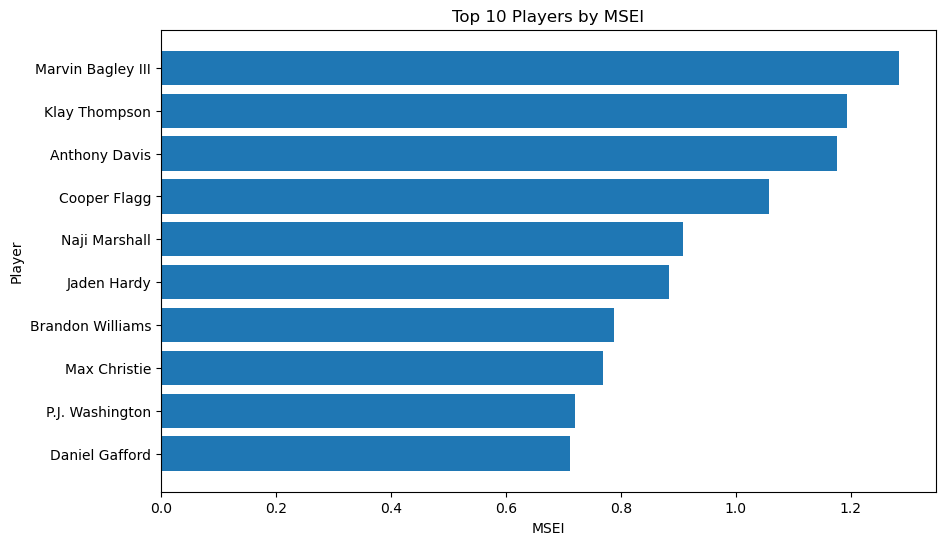

In [31]:
import matplotlib.pyplot as plt

top_msei = (
    qualified_players
    .sort_values("MSEI", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_msei["Player"],
    top_msei["MSEI"]
)

plt.xlabel("MSEI")
plt.ylabel("Player")
plt.title("Top 10 Players by MSEI")

plt.gca().invert_yaxis()

plt.show()

### Observations

- Marvin Bagley III recorded the highest MSEI score among qualified players, indicating the strongest combination of scoring efficiency, projected scoring output, and turnover control.

- Klay Thompson and Anthony Davis ranked second and third, demonstrating strong overall offensive efficiency despite different scoring profiles.

- Cooper Flagg ranked fourth and remained among the top performers due to his high projected scoring output, even though his shooting efficiency was slightly below the team average.

- The gap between Marvin Bagley III and the rest of the group suggests that his balance of efficiency and ball security contributed significantly to his overall MSEI score.

- Most players in the Top 10 recorded MSEI values between approximately 0.7 and 1.3, indicating a relatively competitive distribution among the Mavericks' primary rotation players.

### ข้อสังเกต

- Marvin Bagley III มีค่า MSEI สูงที่สุดในกลุ่มผู้เล่นที่ผ่านเกณฑ์ แสดงถึงความสมดุลระหว่างปริมาณการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอล

- Klay Thompson และ Anthony Davis อยู่ในอันดับที่ 2 และ 3 ตามลำดับ สะท้อนให้เห็นถึงประสิทธิภาพเกมรุกโดยรวมที่แข็งแกร่ง

- Cooper Flagg อยู่ในอันดับที่ 4 โดยได้รับประโยชน์จากความสามารถในการทำคะแนนต่อ 36 นาทีที่สูง แม้ว่าประสิทธิภาพการยิงจะต่ำกว่าค่าเฉลี่ยของกลุ่มเล็กน้อย

- ช่องว่างระหว่าง Marvin Bagley III กับผู้เล่นคนอื่นแสดงให้เห็นว่าประสิทธิภาพการยิงและอัตราการเสียบอลที่ดีมีผลอย่างมากต่อค่า MSEI

- ผู้เล่นส่วนใหญ่ใน Top 10 มีค่า MSEI อยู่ในช่วงประมาณ 0.7–1.3 ซึ่งสะท้อนถึงการแข่งขันที่ค่อนข้างสูสีในกลุ่มผู้เล่นหลักของทีม

### 12.2 Projected Scoring Output vs True Shooting Percentage

This scatter plot compares projected scoring output per 36 minutes with shooting efficiency. It helps identify players who combine both high scoring volume and efficient shooting.

กราฟนี้เปรียบเทียบจำนวนแต้มที่คาดการณ์ต่อ 36 นาที กับประสิทธิภาพการยิง เพื่อค้นหาผู้เล่นที่มีทั้งปริมาณการทำคะแนนและประสิทธิภาพการยิงในระดับสูง

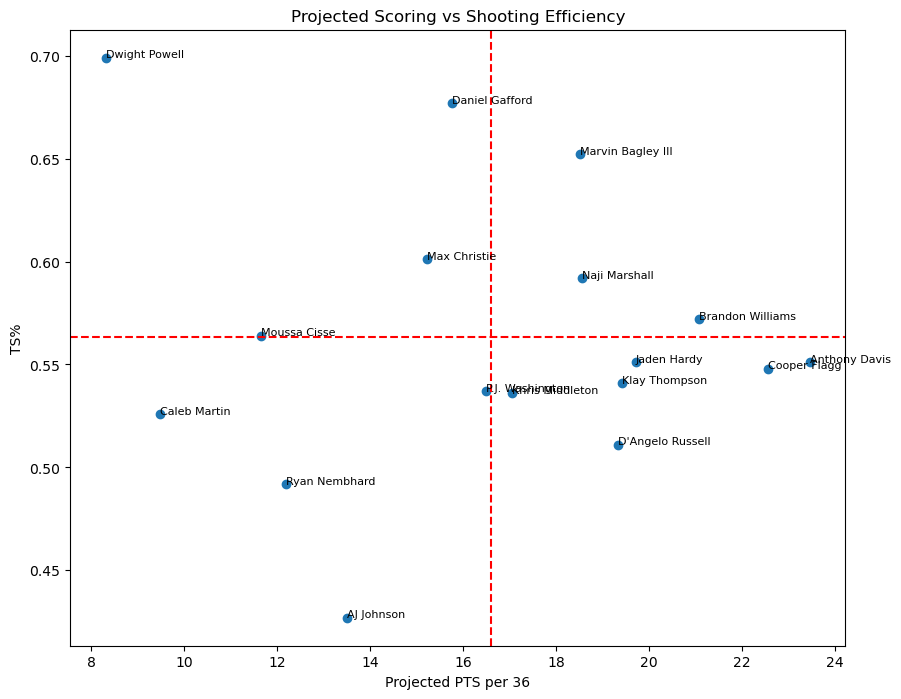

In [32]:
x_mean = qualified_players["Projected_PTS_36"].mean()
y_mean = qualified_players["TS%"].mean()

plt.figure(figsize=(10,8))

plt.scatter(
    qualified_players["Projected_PTS_36"],
    qualified_players["TS%"]
)

for _, row in qualified_players.iterrows():
    plt.annotate(
        row["Player"],
        (row["Projected_PTS_36"], row["TS%"]),
        fontsize=8
    )

plt.axvline(
    x_mean,
    color="red",
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    y_mean,
    color="red",
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Projected PTS per 36")
plt.ylabel("TS%")
plt.title("Projected Scoring vs Shooting Efficiency")

plt.show()

### Quadrant Interpretation

Q1 (Upper Right): High Volume, High Efficiency
- ทำคะแนนได้มาก และมีประสิทธิภาพการยิงสูง

Q2 (Upper Left): Low Volume, High Efficiency
- ทำคะแนนไม่มาก แต่ยิงได้อย่างมีประสิทธิภาพ

Q3 (Lower Left): Low Volume, Low Efficiency
- ทำคะแนนน้อย และมีประสิทธิภาพการยิงต่ำ

Q4 (Lower Right): High Volume, Low Efficiency
- ทำคะแนนได้มาก แต่มีประสิทธิภาพการยิงต่ำ

### Observations

- Marvin Bagley III, Naji Marshall, and Brandon Williams are located in Q1, indicating above-average scoring volume and above-average shooting efficiency.
- Dwight Powell and Daniel Gafford appear in Q2, showing strong shooting efficiency despite lower scoring volume.
- AJ Johnson and Ryan Nembhard appear in Q3, indicating below-average scoring volume and shooting efficiency.
- Anthony Davis and Cooper Flagg are located in Q4, indicating high projected scoring output but below-average True Shooting Percentage relative to the qualified player group.

### ข้อสังเกต

- Marvin Bagley III, Naji Marshall และ Brandon Williams จัดอยู่ในกลุ่ม Q1 (High Volume, High Efficiency) ซึ่งเป็นกลุ่มที่มีทั้งความสามารถในการทำคะแนนและประสิทธิภาพการยิงอยู่ในระดับสูง

- Dwight Powell และ Daniel Gafford อยู่ในกลุ่ม Q2 (Low Volume, High Efficiency) แสดงให้เห็นว่าผู้เล่นทั้งสองมีประสิทธิภาพการยิงที่ดี แม้จะไม่ได้มีบทบาทหลักด้านการทำคะแนน

- AJ Johnson และ Ryan Nembhard อยู่ในกลุ่ม Q3 (Low Volume, Low Efficiency) ซึ่งมีทั้งปริมาณการทำคะแนนและประสิทธิภาพการยิงต่ำกว่าค่าเฉลี่ย

- Anthony Davis และ Cooper Flagg อยู่ในกลุ่ม Q4 (High Volume, Low Efficiency) โดยมีปริมาณการทำคะแนนสูงกว่าค่าเฉลี่ย แต่ยังมีประสิทธิภาพการยิงต่ำกว่าค่าเฉลี่ยของกลุ่มผู้เล่นที่ผ่านเกณฑ์

### 12.3 True Shooting Percentage vs Turnover Rate

### Description

This scatter plot compares shooting efficiency with turnover rate. It helps identify players who maintain strong scoring efficiency while minimizing turnovers.

กราฟนี้เปรียบเทียบประสิทธิภาพการยิง (TS%) กับอัตราการเสียบอล (TOV%) เพื่อระบุผู้เล่นที่สามารถทำคะแนนได้อย่างมีประสิทธิภาพพร้อมกับควบคุมการเสียบอลได้ดี

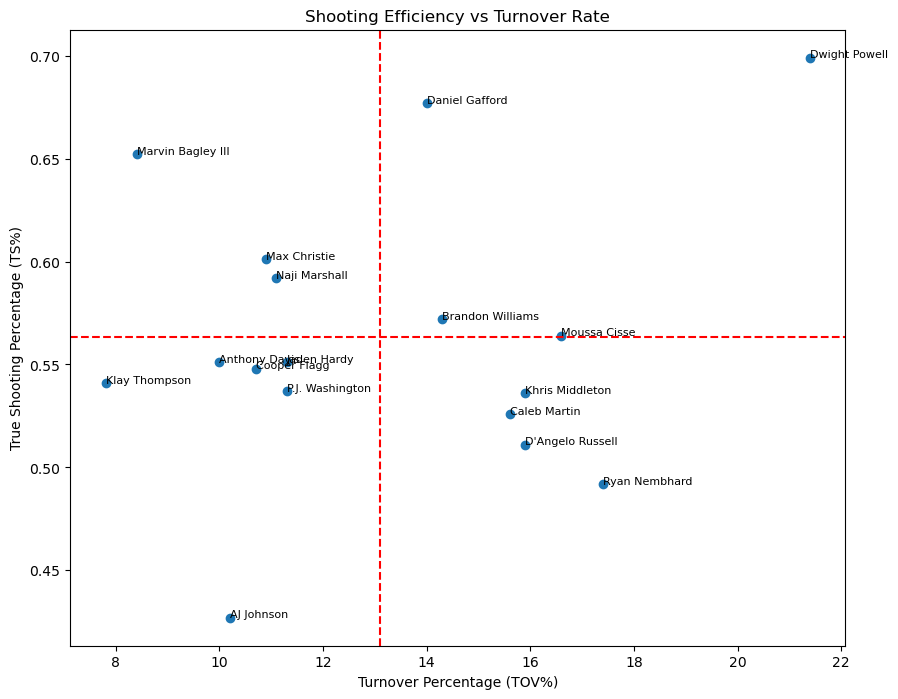

In [33]:
import matplotlib.pyplot as plt

x_mean = qualified_players["TOV%"].mean()
y_mean = qualified_players["TS%"].mean()

plt.figure(figsize=(10,8))

plt.scatter(
    qualified_players["TOV%"],
    qualified_players["TS%"]
)

for _, row in qualified_players.iterrows():
    plt.annotate(
        row["Player"],
        (row["TOV%"], row["TS%"]),
        fontsize=8
    )

plt.axvline(
    x_mean,
    color="red",
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    y_mean,
    color="red",
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Turnover Percentage (TOV%)")
plt.ylabel("True Shooting Percentage (TS%)")
plt.title("Shooting Efficiency vs Turnover Rate")

plt.show()

### Quadrant Meaning

#### English

- Q1 = High Efficiency, Low Turnover
- Q2 = High Efficiency, High Turnover
- Q3 = Low Efficiency, Low Turnover
- Q4 = Low Efficiency, High Turnover

#### ภาษาไทย

- Q1 = ประสิทธิภาพการยิงสูง, อัตราการเสียบอลต่ำ
- Q2 = ประสิทธิภาพการยิงสูง, อัตราการเสียบอลสูง
- Q3 = ประสิทธิภาพการยิงต่ำ, อัตราการเสียบอลต่ำ
- Q4 = ประสิทธิภาพการยิงต่ำ, อัตราการเสียบอลสูง

### Observations

#### English

- Marvin Bagley III, Daniel Gafford, Max Christie, and Naji Marshall are located in Q1, indicating above-average shooting efficiency while maintaining below-average turnover rates.

- Dwight Powell appears in Q2, demonstrating elite shooting efficiency but a higher turnover rate than the team average.

- Klay Thompson, Anthony Davis, Cooper Flagg, and P.J. Washington are located in Q3, showing strong ball security but below-average True Shooting Percentage relative to the qualified player group.

- Ryan Nembhard, D'Angelo Russell, Caleb Martin, and Khris Middleton appear in Q4, indicating both below-average shooting efficiency and above-average turnover rates.

- Marvin Bagley III and Daniel Gafford stand out as the most balanced players in this comparison because they combine high shooting efficiency with relatively low turnover rates.

#### ภาษาไทย

- Marvin Bagley III, Daniel Gafford, Max Christie และ Naji Marshall อยู่ใน Q1 ซึ่งแสดงว่ามีประสิทธิภาพการยิงสูงกว่าค่าเฉลี่ย พร้อมทั้งมีอัตราการเสียบอลต่ำกว่าค่าเฉลี่ย

- Dwight Powell อยู่ใน Q2 แสดงถึงประสิทธิภาพการยิงที่โดดเด่นมาก แต่มีอัตราการเสียบอลสูงกว่าค่าเฉลี่ยของทีม

- Klay Thompson, Anthony Davis, Cooper Flagg และ P.J. Washington อยู่ใน Q3 แสดงว่าควบคุมการเสียบอลได้ดี แต่มีค่า True Shooting Percentage ต่ำกว่าค่าเฉลี่ยของกลุ่มผู้เล่นที่ผ่านเกณฑ์

- Ryan Nembhard, D'Angelo Russell, Caleb Martin และ Khris Middleton อยู่ใน Q4 ซึ่งสะท้อนว่าทั้งประสิทธิภาพการยิงและการควบคุมการเสียบอลต่ำกว่าค่าเฉลี่ย

- Marvin Bagley III และ Daniel Gafford เป็นผู้เล่นที่โดดเด่นที่สุดในกราฟนี้ เนื่องจากสามารถรักษาประสิทธิภาพการยิงในระดับสูงพร้อมกับควบคุมการเสียบอลได้อย่างมีประสิทธิภาพ



### 12.4 Mavericks Scoring Efficiency Index (MSEI) Ranking

### Description

This chart displays the top qualified players ranked by the Mavericks Scoring Efficiency Index (MSEI). The metric combines projected scoring output, shooting efficiency, and turnover control into a single performance measure.

กราฟนี้แสดงอันดับผู้เล่นที่ผ่านเกณฑ์โดยเรียงตามค่า Mavericks Scoring Efficiency Index (MSEI) ซึ่งเป็นตัวชี้วัดที่รวมความสามารถในการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอลไว้ในค่าเดียว

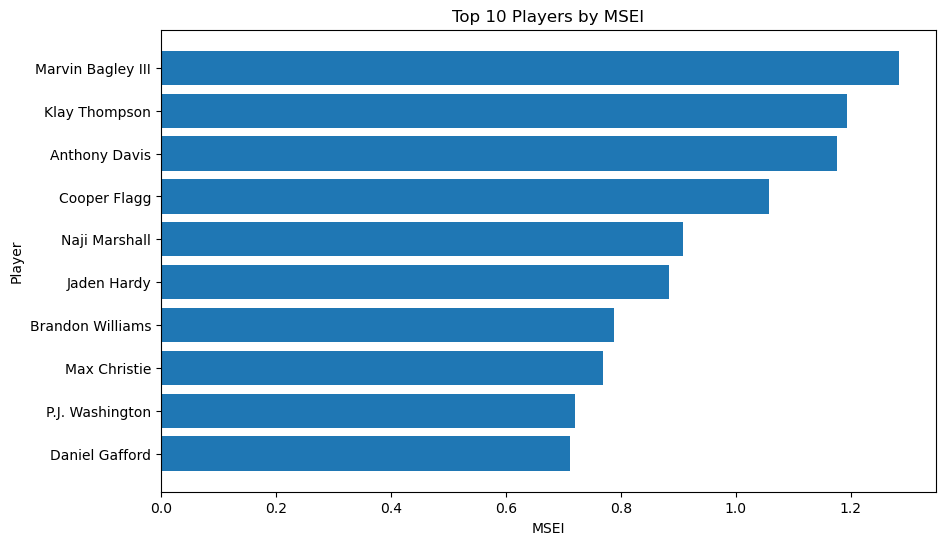

In [34]:
import matplotlib.pyplot as plt

top_msei = (
    qualified_players
    .sort_values("MSEI", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_msei["Player"],
    top_msei["MSEI"]
)

plt.gca().invert_yaxis()

plt.xlabel("MSEI")
plt.ylabel("Player")
plt.title("Top 10 Players by MSEI")

plt.show()

### Observations

#### English

- Marvin Bagley III recorded the highest MSEI value among qualified players, indicating the strongest combination of scoring output, shooting efficiency, and turnover control.

- Klay Thompson and Anthony Davis ranked second and third, demonstrating strong overall scoring efficiency despite different scoring profiles.

- Cooper Flagg ranked fourth in MSEI, supported by his high projected scoring output and solid overall offensive performance.

- Naji Marshall and Jaden Hardy also performed well, placing within the top six players based on the combined efficiency metric.

- The top-ranked players generally balanced scoring production, shooting efficiency, and ball security, which are the key components of the MSEI calculation.

#### ภาษาไทย

- Marvin Bagley III มีค่า MSEI สูงที่สุดในกลุ่มผู้เล่นที่ผ่านเกณฑ์ แสดงถึงการผสมผสานระหว่างการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอลได้ดีที่สุด

- Klay Thompson และ Anthony Davis อยู่ในอันดับที่ 2 และ 3 ตามลำดับ สะท้อนถึงประสิทธิภาพเกมรุกโดยรวมที่แข็งแกร่ง แม้จะมีรูปแบบการทำคะแนนแตกต่างกัน

- Cooper Flagg อยู่ในอันดับที่ 4 ของ MSEI โดยได้รับแรงสนับสนุนจากความสามารถในการทำคะแนนที่โดดเด่นและผลงานเกมรุกที่สม่ำเสมอ

- Naji Marshall และ Jaden Hardy มีผลงานที่น่าสนใจเช่นกัน โดยติดอยู่ในกลุ่ม 6 อันดับแรกของการจัดอันดับตามตัวชี้วัด MSEI

- ผู้เล่นที่มีค่า MSEI สูงส่วนใหญ่สามารถรักษาสมดุลระหว่างปริมาณการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอลได้ดี ซึ่งเป็นองค์ประกอบสำคัญของตัวชี้วัดนี้

## 13. Player Clustering Analysis

### 13.1 Objective

The objective of this section is to group players with similar scoring characteristics using K-Means clustering. This allows players to be categorized based on scoring volume, shooting efficiency, and turnover control.

วัตถุประสงค์ของส่วนนี้คือการจัดกลุ่มผู้เล่นที่มีลักษณะการทำคะแนนใกล้เคียงกันด้วยวิธี K-Means Clustering เพื่อจำแนกประเภทผู้เล่นตามปริมาณการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอล

### 13.2 Feature Selection

In [35]:
cluster_features = qualified_players[
    [
        "Projected_PTS_36",
        "TS%",
        "TOV%"
    ]
]

cluster_features.head()

,Projected_PTS_36,TS%,TOV%
0,22.567164,0.548,10.7
1,23.463259,0.551,10.0
2,16.490323,0.537,11.3
3,18.549153,0.592,11.1
4,15.216495,0.601,10.9


### 13.3 Feature Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

### 13.4 K-Means Clustering

In [37]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="sklearn"
)
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

qualified_players["Cluster"] = kmeans.fit_predict(
    scaled_features
)

qualified_players[
    ["Player", "Cluster"]
].head()

,Player,Cluster
0,Cooper Flagg,1
1,Anthony Davis,1
2,P.J. Washington,1
3,Naji Marshall,1
4,Max Christie,3


### 13.5 Cluster Profiling

In [38]:
cluster_summary = (
    qualified_players
    .groupby("Cluster")[
        [
            "Projected_PTS_36",
            "PTS_per_FGA",
            "TS_Impact",
            "MSEI"
        ]
    ]
    .mean()
    .round(3)
)

cluster_summary

,Projected_PTS_36,PTS_per_FGA,TS_Impact,MSEI
Cluster,,,,
0,12.777,1.175,2.972,0.411
1,20.075,1.235,7.769,0.914
2,8.308,2.062,2.307,0.259
3,16.494,1.481,6.999,0.921


## 13.6 View Players Inside Each Cluster

In [39]:
qualified_players[
    ["Player","Cluster"]
].sort_values(
    by="Cluster"
)

,Player,Cluster
15,Caleb Martin,0
17,Moussa Cisse,0
10,Ryan Nembhard,0
9,Khris Middleton,0
21,AJ Johnson,0
0,Cooper Flagg,1
2,P.J. Washington,1
1,Anthony Davis,1
19,Jaden Hardy,1
12,D'Angelo Russell,1


Cluster names were assigned based on the average values of Projected_PTS_36, PTS_per_FGA, TS_Impact, and MSEI from the cluster summary table.

ชื่อของแต่ละกลุ่มถูกกำหนดจากค่าเฉลี่ยของ Projected_PTS_36, PTS_per_FGA, TS_Impact และ MSEI ในตารางสรุป Cluster

## 13.7 Assign Cluster Names

In [40]:
cluster_map = {
    0: "Low Impact Players",
    1: "Volume Scorers",
    2: "Efficient Specialists",
    3: "Efficient Scorers"
}

qualified_players["Cluster_Name"] = (
    qualified_players["Cluster"]
    .map(cluster_map)
)

## 13.8 Final Cluster Table

In [41]:
qualified_players[
    ["Player","Cluster_Name"]
].sort_values(
    by="Cluster_Name"
)

,Player,Cluster_Name
8,Marvin Bagley III,Efficient Scorers
4,Max Christie,Efficient Scorers
7,Daniel Gafford,Efficient Scorers
16,Dwight Powell,Efficient Specialists
17,Moussa Cisse,Low Impact Players
15,Caleb Martin,Low Impact Players
10,Ryan Nembhard,Low Impact Players
9,Khris Middleton,Low Impact Players
21,AJ Johnson,Low Impact Players
6,Klay Thompson,Volume Scorers


## 13.9 Cluster Visualization

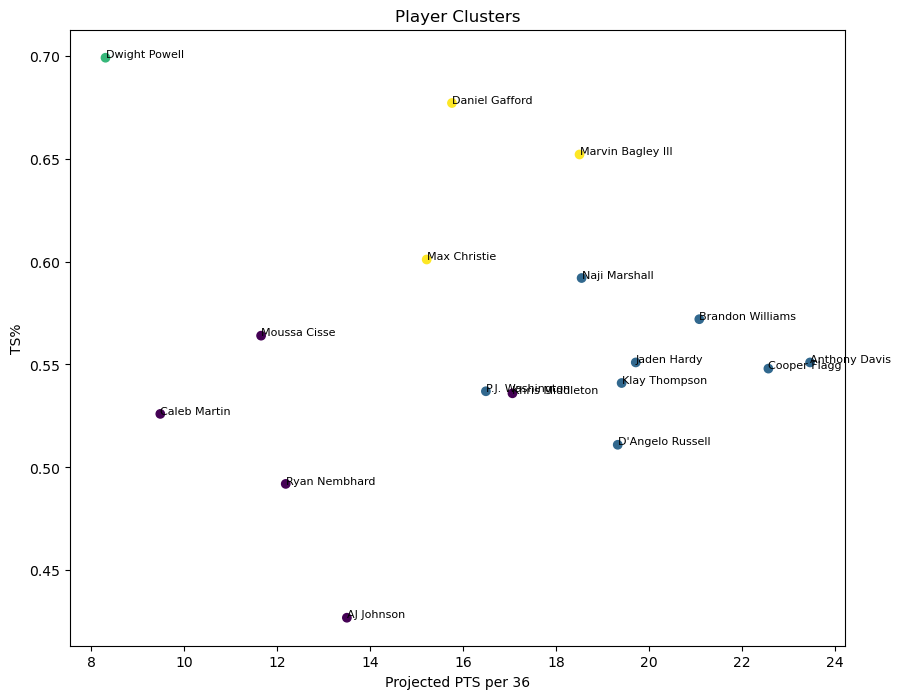

In [42]:
plt.figure(figsize=(10,8))

plt.scatter(
    qualified_players["Projected_PTS_36"],
    qualified_players["TS%"],
    c=qualified_players["Cluster"]
)

for _, row in qualified_players.iterrows():
    plt.annotate(
        row["Player"],
        (row["Projected_PTS_36"], row["TS%"]),
        fontsize=8
    )

plt.xlabel("Projected PTS per 36")
plt.ylabel("TS%")
plt.title("Player Clusters")

plt.show()

### Observations

- K-Means clustering identified four distinct player archetypes based on scoring volume, shooting efficiency, and turnover control.

- Efficient Scorers (Marvin Bagley III, Daniel Gafford, and Max Christie) demonstrated strong shooting efficiency while maintaining solid scoring production.

- Volume Scorers formed the largest cluster and included players such as Anthony Davis, Cooper Flagg, and Klay Thompson. These players generated higher scoring output but displayed varying levels of efficiency.

- Dwight Powell was classified as an Efficient Specialist due to his exceptional shooting efficiency despite a relatively small offensive role.

- Low Impact Players, including AJ Johnson and Ryan Nembhard, recorded lower scoring production and overall offensive impact compared with the other clusters.

### ข้อสังเกต

- K-Means Clustering สามารถแบ่งผู้เล่นออกเป็น 4 กลุ่มตามลักษณะการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอล

- กลุ่ม Efficient Scorers ได้แก่ Marvin Bagley III, Daniel Gafford และ Max Christie ซึ่งมีประสิทธิภาพการยิงสูงพร้อมกับสร้างคะแนนได้ในระดับที่ดี

- กลุ่ม Volume Scorers เป็นกลุ่มที่มีจำนวนผู้เล่นมากที่สุด โดยมี Anthony Davis, Cooper Flagg และ Klay Thompson เป็นตัวอย่างของผู้เล่นที่สร้างคะแนนได้สูง แม้ว่าประสิทธิภาพการยิงจะแตกต่างกันในแต่ละคน

- Dwight Powell ถูกจัดอยู่ในกลุ่ม Efficient Specialists เนื่องจากมีประสิทธิภาพการยิงสูงมาก แม้จะมีบทบาทในการทำคะแนนไม่มากนัก

- กลุ่ม Low Impact Players เช่น AJ Johnson และ Ryan Nembhard มีผลงานด้านการทำคะแนนและผลกระทบเชิงรุกต่ำกว่ากลุ่มอื่นในชุดข้อมูล

# 14. Conclusion

This project analyzed the scoring performance of Dallas Mavericks players using traditional basketball statistics, custom feature engineering, and unsupervised machine learning techniques.

Several new metrics were created, including PTS_per_Min, Projected_PTS_36, PTS_per_FGA, TS_Impact, and the Mavericks Scoring Efficiency Index (MSEI). These metrics provided additional insight into scoring volume, shooting efficiency, and overall offensive contribution.

The MSEI ranking identified Marvin Bagley III as the top-performing player among qualified players, followed by Klay Thompson and Anthony Davis. These players demonstrated strong combinations of scoring efficiency, scoring output, and ball security.

Scatter plot analysis revealed different player profiles across scoring volume, shooting efficiency, and turnover control. Players such as Marvin Bagley III and Daniel Gafford consistently appeared in favorable areas of multiple visualizations, indicating efficient offensive performance.

K-Means clustering further grouped players into four distinct categories:

- Efficient Scorers
- Volume Scorers
- Efficient Specialists
- Low Impact Players

The clustering results showed that different players contribute in different ways. Some players generate high scoring volume, while others provide value through efficient shot selection and lower turnover rates.

Overall, the analysis demonstrates that combining advanced metrics with clustering techniques provides a more comprehensive evaluation of player scoring performance than relying on traditional statistics alone.

## สรุปผลการวิเคราะห์

โครงการนี้วิเคราะห์ประสิทธิภาพการทำคะแนนของผู้เล่น Dallas Mavericks โดยใช้สถิติบาสเกตบอลแบบดั้งเดิม ร่วมกับการสร้างตัวแปรใหม่ (Feature Engineering) และเทคนิคการจัดกลุ่มข้อมูลแบบ K-Means Clustering

มีการพัฒนาตัวชี้วัดเพิ่มเติม ได้แก่ PTS_per_Min, Projected_PTS_36, PTS_per_FGA, TS_Impact และ Mavericks Scoring Efficiency Index (MSEI) เพื่อช่วยประเมินทั้งปริมาณการทำคะแนน ประสิทธิภาพการยิง และผลกระทบเชิงรุกโดยรวมของผู้เล่น

ผลการจัดอันดับด้วย MSEI พบว่า Marvin Bagley III มีคะแนน MSEI สูงที่สุด รองลงมาคือ Klay Thompson และ Anthony Davis ซึ่งแสดงให้เห็นถึงความสมดุลระหว่างความสามารถในการทำคะแนน ประสิทธิภาพการยิง และการควบคุมการเสียบอล

การวิเคราะห์ด้วย Scatter Plot ช่วยให้เห็นรูปแบบของผู้เล่นในหลายมิติ โดย Marvin Bagley III และ Daniel Gafford ปรากฏอยู่ในตำแหน่งที่โดดเด่นในหลายกราฟ สะท้อนถึงประสิทธิภาพเกมรุกที่แข็งแกร่ง

นอกจากนี้ K-Means Clustering สามารถแบ่งผู้เล่นออกเป็น 4 กลุ่ม ได้แก่

- Efficient Scorers
- Volume Scorers
- Efficient Specialists
- Low Impact Players

ผลการจัดกลุ่มแสดงให้เห็นว่าผู้เล่นแต่ละคนสร้างคุณค่าให้ทีมในรูปแบบที่แตกต่างกัน บางคนโดดเด่นด้านปริมาณการทำคะแนน ขณะที่บางคนมีจุดเด่นด้านประสิทธิภาพการยิงและการควบคุมการเสียบอล

โดยสรุป การผสมผสานระหว่างตัวชี้วัดขั้นสูงและเทคนิคการจัดกลุ่มข้อมูลช่วยให้สามารถประเมินประสิทธิภาพการทำคะแนนของผู้เล่นได้ครอบคลุมมากกว่าการพิจารณาจากสถิติพื้นฐานเพียงอย่างเดียว